# Shopping Dataset - Exploratory Data Analysis

Analysing the combined shopping dataset to understand product trends, pricing patterns and customer preferences across different product categories.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# suppressing unnecessary warnings for cleaner output
warnings.filterwarnings('ignore')

# setting up plot aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 1: Load the Data

In [56]:
df = pd.read_csv('../data/Combined_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")

Dataset Shape: (1000, 24)
Total Rows: 1000
Total Columns: 24

Column Names:
['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'what_customers_said', 'seller_name', 'sizes', 'videos', 'seller_information', 'variations', 'best_offer', 'more_offers', 'category']


In [57]:
# previewing first few rows to understand the structure
df.head(3)

,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,delivery_options,product_details,breadcrumbs,product_specifications,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,"[""100% Original Products"",""Pay on delivery mig...","{""description"":""Navy Blue solid backpackNon-Pa...","[{""name"":""Accessories"",""url"":""https://www.mynt...","[{""specification_name"":""Add-Ons"",""specificatio...","{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,"[""100% Original Products"",""Pay on delivery mig...","{""description"":""Navy Blue backpackNon-Padded h...","[{""name"":""Accessories"",""url"":""https://www.mynt...","[{""specification_name"":""Add-Ons"",""specificatio...","{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,"[""100% Original Products"",""Pay on delivery mig...","{""description"":""Pink solid backpacks Non-padd...","[{""name"":""Accessories"",""url"":""https://www.mynt...","[{""specification_name"":""Add-Ons"",""specificatio...","{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks


## Step 2: Understanding the Data

In [58]:
# checking data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              1000 non-null   int64  
 1   title                   1000 non-null   str    
 2   product_description     1000 non-null   str    
 3   rating                  1000 non-null   float64
 4   ratings_count           1000 non-null   int64  
 5   initial_price           1000 non-null   int64  
 6   discount                879 non-null    float64
 7   final_price             1000 non-null   str    
 8   currency                1000 non-null   str    
 9   images                  1000 non-null   str    
 10  delivery_options        1000 non-null   str    
 11  product_details         1000 non-null   str    
 12  breadcrumbs             1000 non-null   str    
 13  product_specifications  1000 non-null   str    
 14  amount_of_stars         1000 non-null   str    
 15 

In [59]:
# checking how many values are missing in each column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': round(missing_pct, 2)
})

# only showing columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:\n")
print(missing_df)

Columns with missing values:

                     Missing Count  Missing %
videos                         781       78.1
what_customers_said            573       57.3
variations                     562       56.2
seller_name                    301       30.1
seller_information             301       30.1
discount                       121       12.1


In [60]:
# summary statistics for numerical columns
df.describe()

,product_id,rating,ratings_count,initial_price,discount
count,1.000000e+03,1000.0000,1000.000000,1000.00000,879.000000
mean,1.713437e+07,3.6215,76.691000,2723.24100,53.503982
std,3.813766e+06,1.3744,241.114263,2408.69736,18.029201
min,5.868460e+05,0.0000,0.000000,249.00000,1.000000
25%,1.511501e+07,3.7000,7.000000,1399.00000,44.000000
50%,1.820890e+07,4.1000,17.000000,1999.00000,56.000000
75%,1.902737e+07,4.3000,58.000000,3299.00000,66.000000
max,2.274707e+07,5.0000,4441.000000,22199.00000,88.000000


**Quick Observations:**
- The dataset contains both numerical and text (object) columns
- `final_price` is stored as text and needs to be converted to a proper numeric format
- Several columns have missing values — `videos`, `what_customers_said` and `seller_name` are the most affected
- `discount` has some missing values, most likely indicating that those products had no discount
- All prices are in INR (Indian Rupees)

## Step 3: Data Cleaning

In [61]:
# the final_price column has rupee symbols, commas and extra quotes
# need to strip all of that out and convert to numeric

print("Before cleaning:")
print(df['final_price'].head().to_string())
print(f"Data type: {df['final_price'].dtype}")

# step by step cleaning
df['final_price'] = df['final_price'].astype(str)
df['final_price'] = df['final_price'].str.replace('"', '', regex=False)
df['final_price'] = df['final_price'].str.replace('₹', '', regex=False)
df['final_price'] = df['final_price'].str.replace(',', '', regex=False)
df['final_price'] = df['final_price'].str.strip()
df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')

print("\nAfter cleaning:")
print(df['final_price'].head())
print(f"Data type: {df['final_price'].dtype}")
print(f"Any NaN values: {df['final_price'].isna().sum()}")

Before cleaning:
0    "₹3,995.00"
1    "₹2,899.00"
2    "₹2,999.00"
3    "₹1,675.00"
4    "₹2,899.00"
Data type: str

After cleaning:
0    3995.0
1    2899.0
2    2999.0
3    1675.0
4    2899.0
Name: final_price, dtype: float64
Data type: float64
Any NaN values: 0


In [62]:
# handling missing values

# discount: if missing, it means no discount was applied
df['discount'] = df['discount'].fillna(0)

# for text columns with missing data, filling with 'Not Available'
text_cols_missing = ['what_customers_said', 'seller_name', 'seller_information', 'videos', 'variations']
for col in text_cols_missing:
    df[col] = df[col].fillna('Not Available')

# checking for duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")

if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Removed {dup_count} duplicates")
else:
    print("No duplicate rows found")

# verify missing values are handled
remaining_missing = df.isnull().sum().sum()
print(f"\nTotal missing values remaining: {remaining_missing}")

Duplicate rows found: 0
No duplicate rows found

Total missing values remaining: 0


In [63]:
# sanity check after cleaning
print("=== Cleaned Dataset Summary ===")
print(f"Shape: {df.shape}")
print(f"\nNumeric columns summary:")
df[['rating', 'ratings_count', 'initial_price', 'discount', 'final_price']].describe()

=== Cleaned Dataset Summary ===
Shape: (1000, 24)

Numeric columns summary:


,rating,ratings_count,initial_price,discount,final_price
count,1000.0000,1000.000000,1000.00000,1000.000000,1000.000000
mean,3.6215,76.691000,2723.24100,47.030000,1706.096000
std,1.3744,241.114263,2408.69736,24.299332,1783.864472
min,0.0000,0.000000,249.00000,0.000000,199.000000
25%,3.7000,7.000000,1399.00000,33.000000,649.000000
50%,4.1000,17.000000,1999.00000,53.000000,1099.000000
75%,4.3000,58.000000,3299.00000,65.000000,2082.250000
max,5.0000,4441.000000,22199.00000,88.000000,17995.000000


In [64]:
# saving the cleaned dataset to a csv file for future use
cleaned_path = '../data/cleaned_data.csv'
df.to_csv(cleaned_path, index=False)
print(f"Cleaned data saved to: {cleaned_path}")
print(f"Shape: {df.shape}")

Cleaned data saved to: ../data/cleaned_data.csv
Shape: (1000, 24)


## Step 4: Feature Engineering

In [65]:
# how much money customers are saving (initial price minus final price)
df['price_difference'] = df['initial_price'] - df['final_price']

print("Sample of price comparison:")
sample = df[['title', 'initial_price', 'final_price', 'price_difference']].head(10)
print(sample.to_string(index=False))

print(f"\nAverage savings: Rs. {df['price_difference'].mean():.2f}")
print(f"Maximum savings: Rs. {df['price_difference'].max():.2f}")

Sample of price comparison:
         title  initial_price  final_price  price_difference
   Lino Perros           3995       3995.0               0.0
Tommy Hilfiger           2899       2899.0               0.0
         Lavie           2999       2999.0               0.0
        F Gear           1675       1675.0               0.0
     MYTRIDENT           2899       2899.0               0.0
           H&M           1399       1399.0               0.0
    AVI Living           1399       1399.0               0.0
       My Room           2999       2999.0               0.0
       My Room           2999       2999.0               0.0
    Story@home           2199       2199.0               0.0

Average savings: Rs. 1017.14
Maximum savings: Rs. 14652.00


In [66]:
# creating a popularity score using rating and number of ratings
# log is used to prevent products with huge review counts from dominating
df['popularity_score'] = df['rating'] * np.log1p(df['ratings_count'])

# top 10 most popular products
print("Top 10 Products by Popularity Score:\n")
top_pop = df.nlargest(10, 'popularity_score')[['title', 'category', 'rating', 'ratings_count', 'popularity_score']]
print(top_pop.to_string(index=False))

Top 10 Products by Popularity Score:

       title          category  rating  ratings_count  popularity_score
   SASSAFRAS           dresses     4.5           4441         37.794870
      Athena           dresses     4.2           3797         34.617366
      Jockey               bra     4.4           1582         32.415139
      F Gear         backpacks     4.4           1052         30.621353
Daniel Klein           watches     4.4            940         30.126550
  HIGHLANDER            shirts     4.2           1246         29.939683
    Roadster       sweatshirts     4.3            959         29.527813
   Mamaearth face-moisturisers     4.3            903         29.269366
        Biba        kurta-sets     4.4            749         29.128322
     Mactree             boots     3.9           1727         29.073408


In [67]:
# extracting number of product images from the images column
df['num_images'] = df['images'].str.split(',').str.len()

print(f"Average images per product: {df['num_images'].mean():.1f}")
print(f"Range: {df['num_images'].min()} to {df['num_images'].max()} images")
print(f"\nNew columns added: price_difference, popularity_score, num_images")

Average images per product: 5.7
Range: 1 to 10 images

New columns added: price_difference, popularity_score, num_images


## Step 5: Analysis

### 5.1 Univariate Analysis
Examining the distribution of individual variables to understand their spread and central tendency.

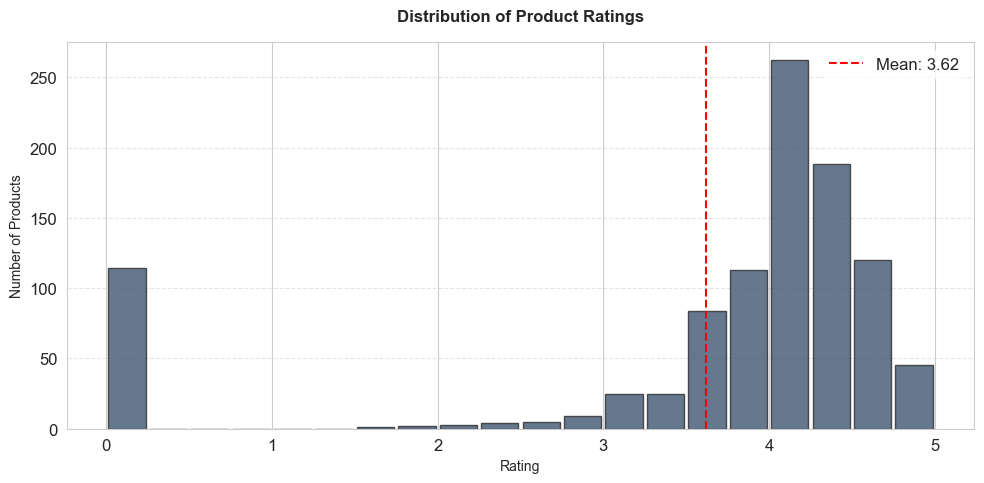

In [68]:
# distribution of product ratings
plt.figure(figsize=(10, 5))
plt.hist(df['rating'], bins=20, color='#4A607A', edgecolor='#333333', alpha=0.85, rwidth=0.9)
plt.title('Distribution of Product Ratings', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Rating', fontsize=10)
plt.ylabel('Number of Products', fontsize=10)
plt.axvline(df['rating'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {df['rating'].mean():.2f}")
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

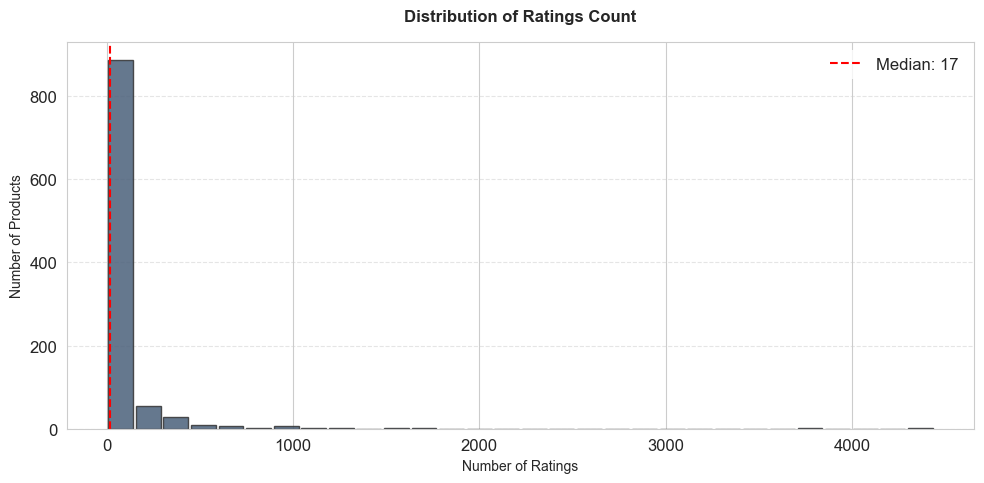

In [69]:
# distribution of how many ratings each product has
plt.figure(figsize=(10, 5))
plt.hist(df['ratings_count'], bins=30, color='#4A607A', edgecolor='#333333', alpha=0.85, rwidth=0.9)
plt.title('Distribution of Ratings Count', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Ratings', fontsize=10)
plt.ylabel('Number of Products', fontsize=10)
plt.axvline(df['ratings_count'].median(), color='red', linestyle='--', linewidth=1.5,
            label=f"Median: {int(df['ratings_count'].median())}")
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

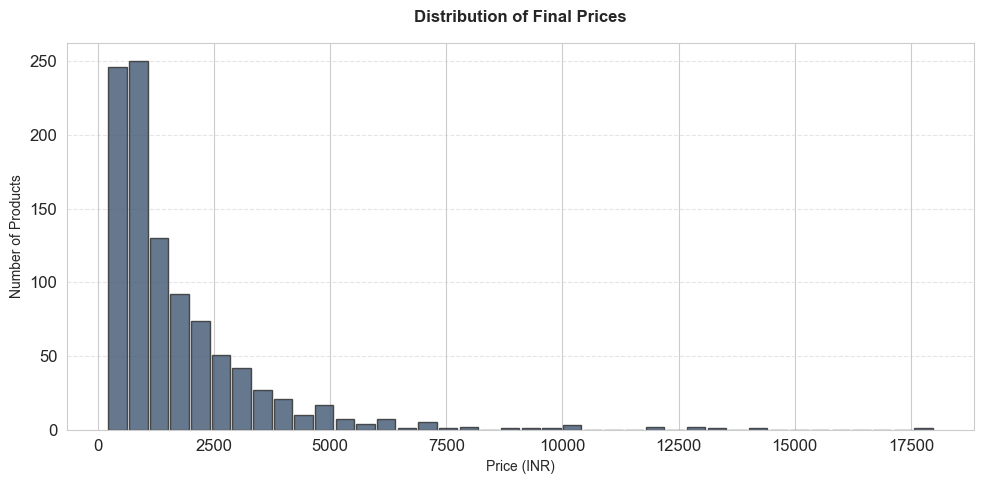

In [70]:
# final price distribution
plt.figure(figsize=(10, 5))
plt.hist(df['final_price'].dropna(), bins=40, color='#4A607A', edgecolor='#333333', alpha=0.85, rwidth=0.9)
plt.title('Distribution of Final Prices', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Price (INR)', fontsize=10)
plt.ylabel('Number of Products', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

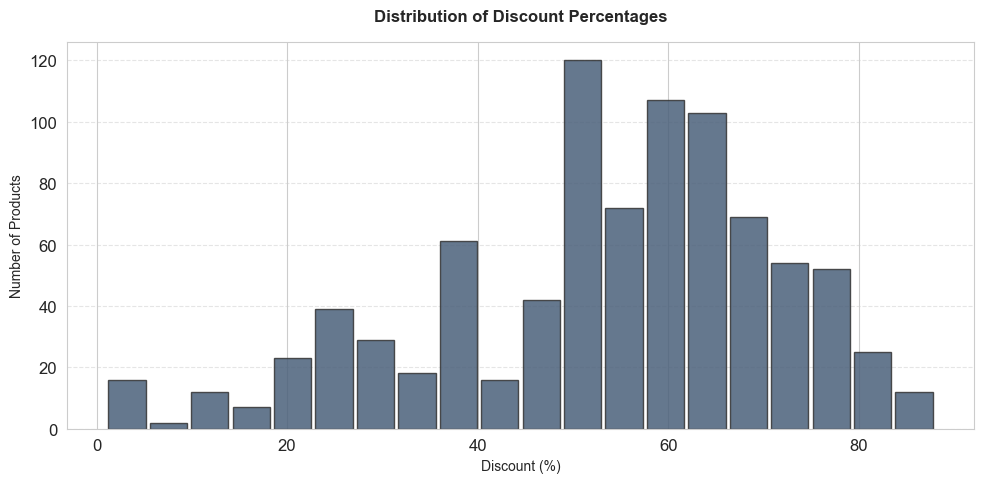

Products with zero discount: 121 out of 1000


In [71]:
# discount percentage distribution (only products with discount > 0)
plt.figure(figsize=(10, 5))
plt.hist(df[df['discount'] > 0]['discount'], bins=20, color='#4A607A', edgecolor='#333333', alpha=0.85, rwidth=0.9)
plt.title('Distribution of Discount Percentages', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Discount (%)', fontsize=10)
plt.ylabel('Number of Products', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Products with zero discount: {(df['discount'] == 0).sum()} out of {len(df)}")

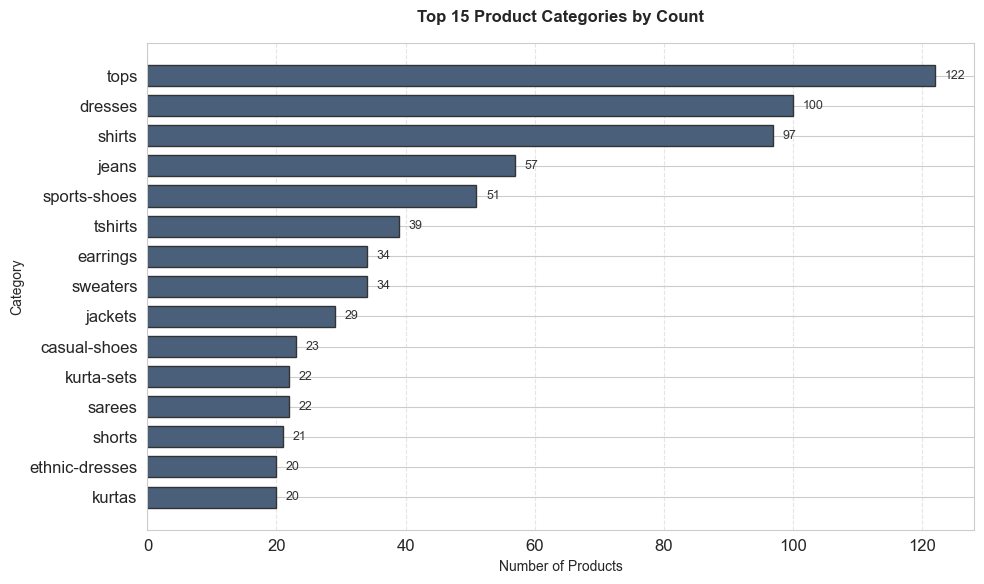


Total unique categories: 97


In [72]:
# top 15 categories by number of products
cat_counts = df['category'].value_counts().head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#4A607A', edgecolor='#333333', height=0.7)
plt.title('Top 15 Product Categories by Count', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Products', fontsize=10)
plt.ylabel('Category', fontsize=10)

# adding count labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1.5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=9, color='#333333')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nTotal unique categories: {df['category'].nunique()}")

### 5.2 Bivariate Analysis
Looking at how two variables relate to each other.

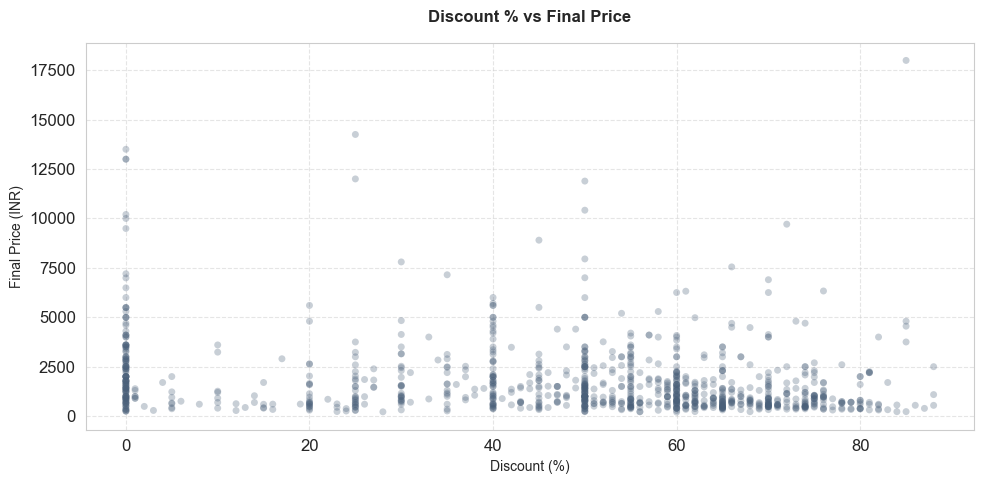

In [73]:
# discount percentage vs final price
plt.figure(figsize=(10, 5))
plt.scatter(df['discount'], df['final_price'], alpha=0.3, color='#4A607A', s=25, edgecolors='none')
plt.title('Discount % vs Final Price', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Discount (%)', fontsize=10)
plt.ylabel('Final Price (INR)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

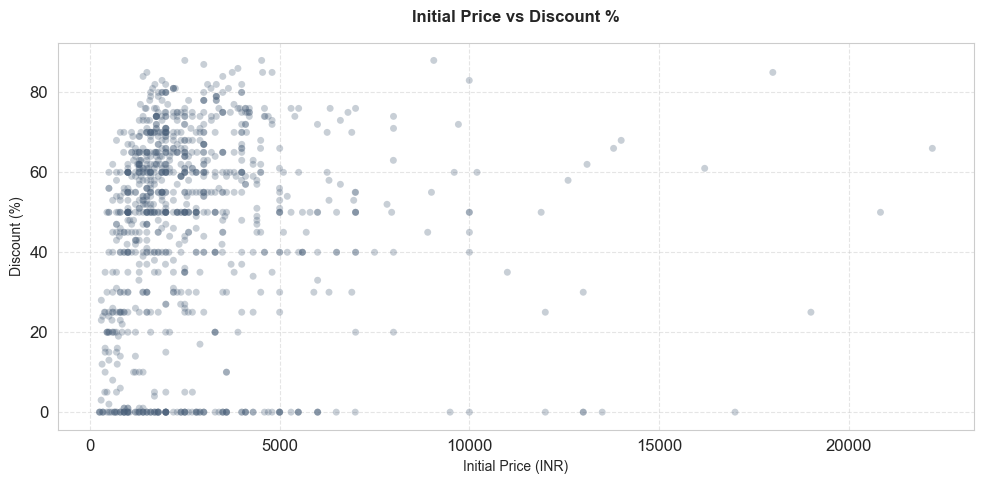

In [74]:
# initial price vs discount percentage
plt.figure(figsize=(10, 5))
plt.scatter(df['initial_price'], df['discount'], alpha=0.3, color='#4A607A', s=25, edgecolors='none')
plt.title('Initial Price vs Discount %', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Initial Price (INR)', fontsize=10)
plt.ylabel('Discount (%)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

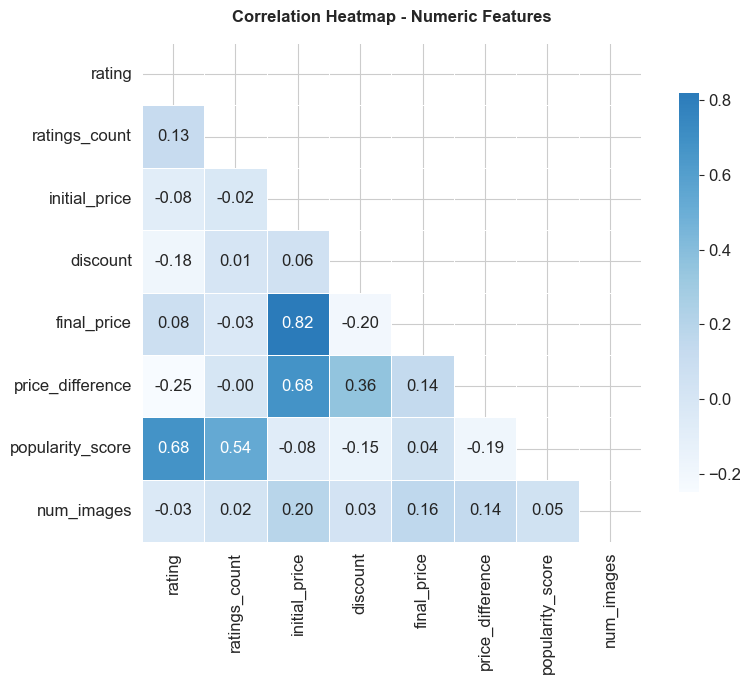

Notable correlations:
  initial_price & final_price: 0.819
  rating & popularity_score: 0.679
  ratings_count & popularity_score: 0.535


In [75]:
# correlation matrix for all numeric columns
numeric_cols = ['rating', 'ratings_count', 'initial_price', 'discount',
                'final_price', 'price_difference', 'popularity_score', 'num_images']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # showing only lower triangle to avoid redundancy
sns.heatmap(corr, annot=True, cmap='Blues', center=0.5, fmt='.2f',
            linewidths=0.5, square=True, mask=mask, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numeric Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# printing out some notable correlations
print("Notable correlations:")
print(f"  initial_price & final_price: {corr.loc['initial_price', 'final_price']:.3f}")
print(f"  rating & popularity_score: {corr.loc['rating', 'popularity_score']:.3f}")
print(f"  ratings_count & popularity_score: {corr.loc['ratings_count', 'popularity_score']:.3f}")

### 5.3 Category-level Analysis
Breaking down key metrics across product categories to identify patterns.

In [76]:
# aggregating metrics by category
cat_stats = df.groupby('category').agg(
    count=('product_id', 'count'),
    avg_rating=('rating', 'mean'),
    avg_price=('final_price', 'mean'),
    avg_discount=('discount', 'mean'),
    avg_popularity=('popularity_score', 'mean'),
    total_reviews=('ratings_count', 'sum')
).round(2)

cat_stats = cat_stats.sort_values('count', ascending=False)

print("Category-wise Summary (Top 15 by product count):\n")
print(cat_stats.head(15).to_string())

Category-wise Summary (Top 15 by product count):

              count  avg_rating  avg_price  avg_discount  avg_popularity  total_reviews
category                                                                               
tops            122        3.45    1245.35         47.94           11.34           5077
dresses         100        3.53    1296.03         54.13           11.89          15462
shirts           97        3.97    1431.90         50.11           13.52           6085
jeans            57        3.83    2173.65         47.23           14.41           4837
sports-shoes     51        4.12    4228.47         22.59           14.55           3243
tshirts          39        3.88    1044.72         42.92           14.87           4715
earrings         34        2.86     746.44         66.59            9.56           2574
sweaters         34        4.15    1605.50         39.06           16.03           3060
jackets          29        3.73    2494.31         46.97           16.

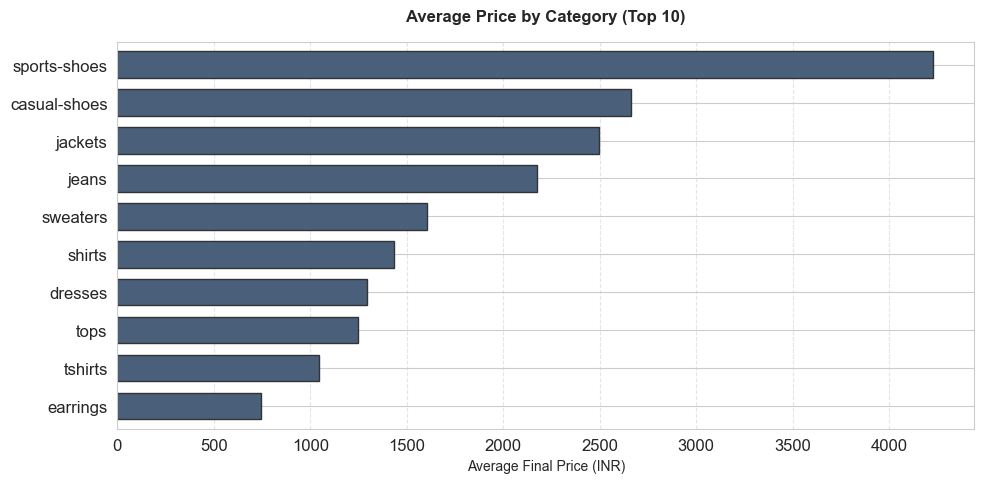

In [77]:
# average final price by category (top 10 categories by product count)
top_cats = df['category'].value_counts().head(10).index
df_top = df[df['category'].isin(top_cats)]

plt.figure(figsize=(10, 5))
avg_price = df_top.groupby('category')['final_price'].mean().sort_values(ascending=True)
avg_price.plot(kind='barh', color='#4A607A', edgecolor='#333333', width=0.7)
plt.title('Average Price by Category (Top 10)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Average Final Price (INR)', fontsize=10)
plt.ylabel('', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

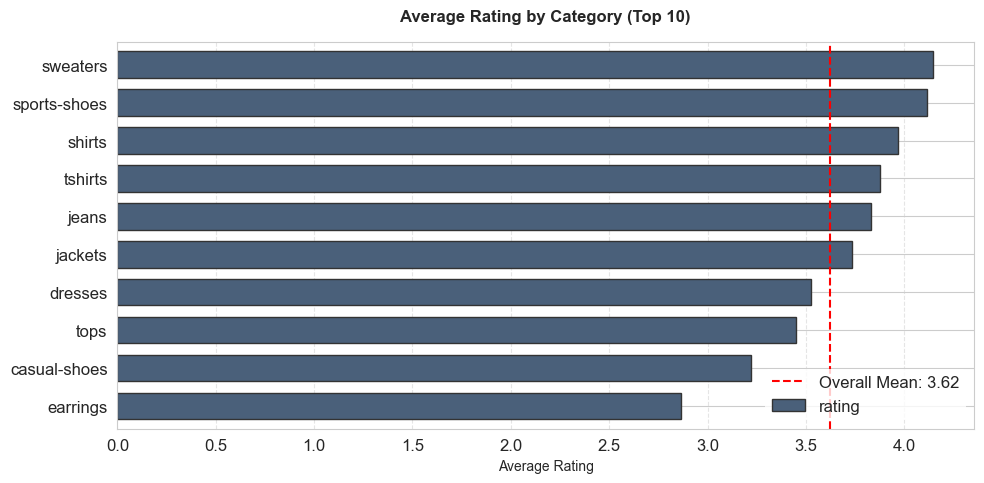

In [78]:
# average rating by category (top 10 categories by product count)
plt.figure(figsize=(10, 5))
avg_rating = df_top.groupby('category')['rating'].mean().sort_values(ascending=True)
avg_rating.plot(kind='barh', color='#4A607A', edgecolor='#333333', width=0.7)
plt.title('Average Rating by Category (Top 10)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Average Rating', fontsize=10)
plt.ylabel('', fontsize=10)
plt.axvline(df['rating'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Overall Mean: {df['rating'].mean():.2f}")
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 6: Visualisation
Comprehensive plots to highlight the main trends and patterns in the data.

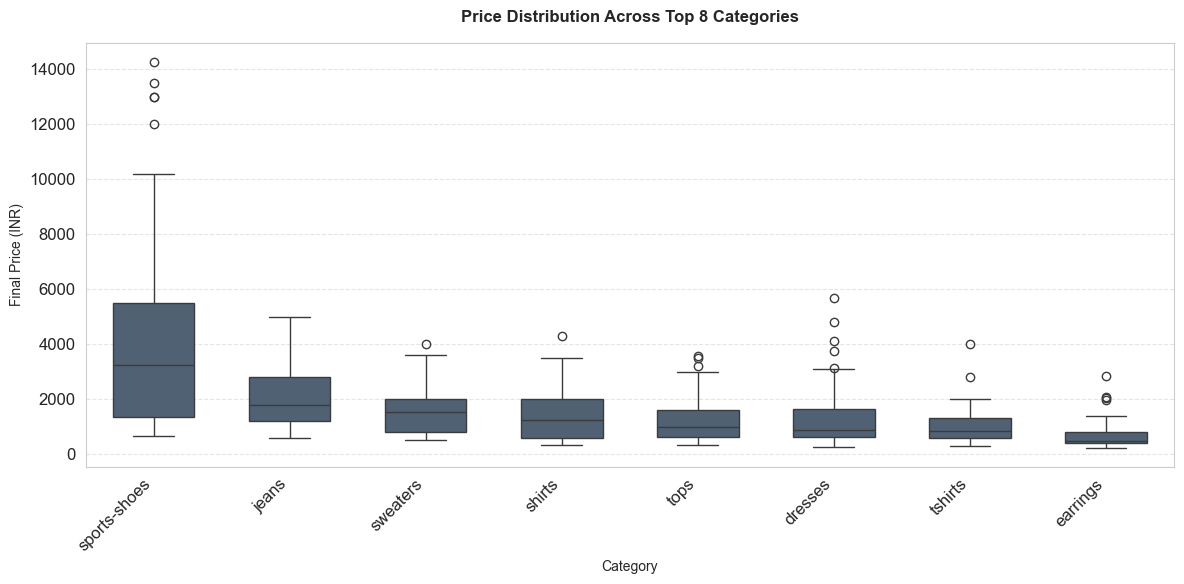

In [79]:
# price spread across top categories using boxplots
top_8_cats = df['category'].value_counts().head(8).index
df_box = df[df['category'].isin(top_8_cats)]

plt.figure(figsize=(12, 6))
order = df_box.groupby('category')['final_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_box, x='category', y='final_price', order=order, color='#4A607A', width=0.6)
plt.title('Price Distribution Across Top 8 Categories', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=10)
plt.ylabel('Final Price (INR)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

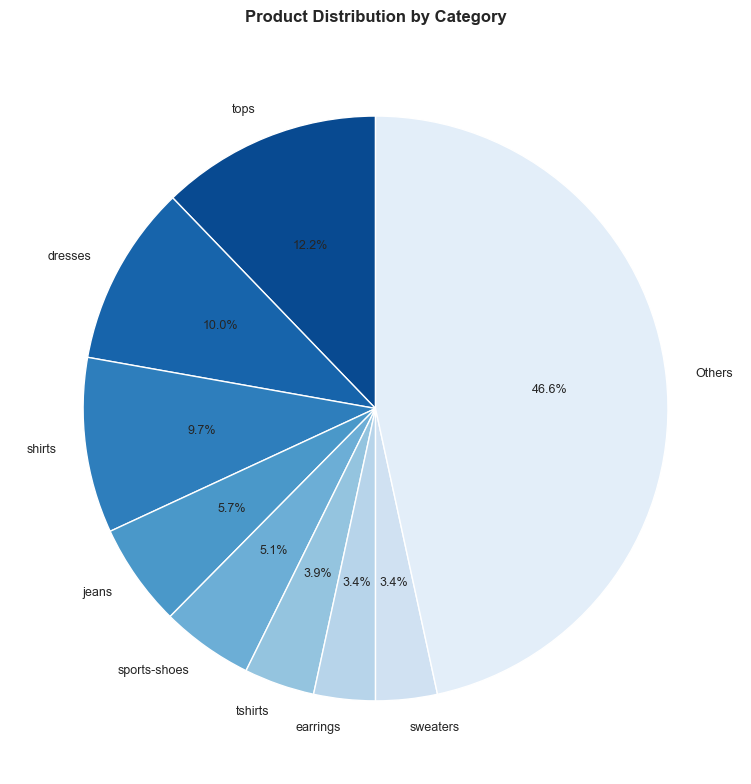

In [80]:
# 1. category distribution - pie chart (top 8 + others)
cat_top8 = df['category'].value_counts().head(8)
others_count = df['category'].value_counts().iloc[8:].sum()
pie_data = pd.concat([cat_top8, pd.Series({'Others': others_count})])

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Blues_r', len(pie_data))
plt.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 9},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Product Distribution by Category', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

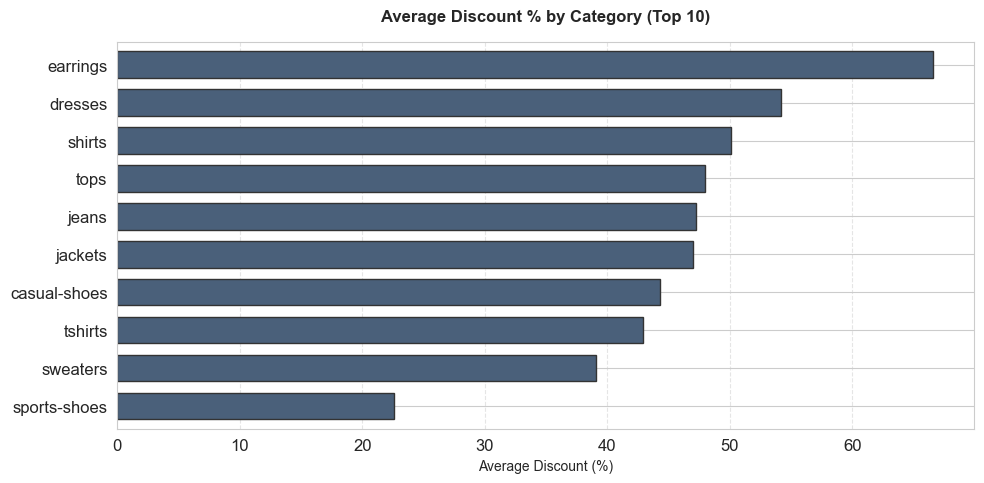

In [81]:
# 2. average discount by top 10 categories
plt.figure(figsize=(10, 5))
avg_disc = df_top.groupby('category')['discount'].mean().sort_values(ascending=True)
avg_disc.plot(kind='barh', color='#4A607A', edgecolor='#333333', width=0.7)
plt.title('Average Discount % by Category (Top 10)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Average Discount (%)', fontsize=10)
plt.ylabel('', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

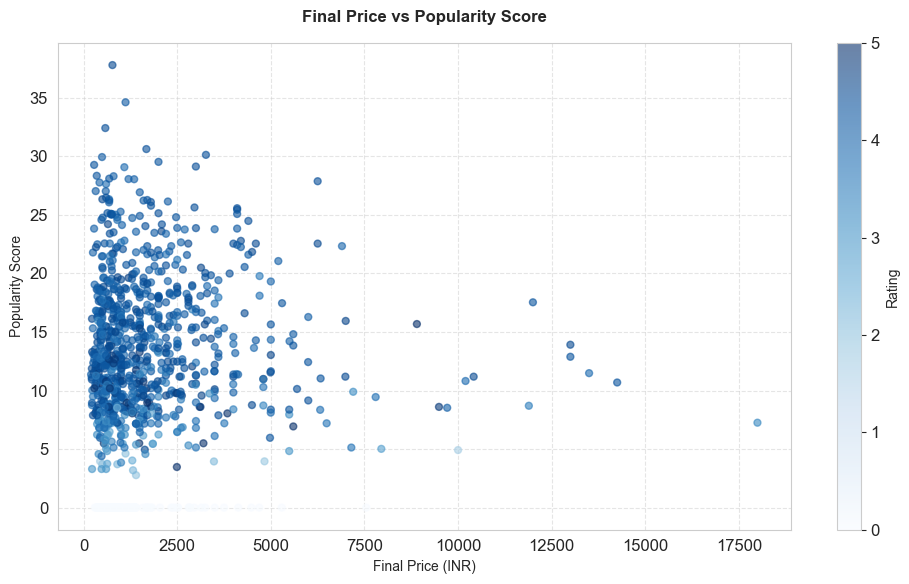

In [82]:
# 3. price vs popularity coloured by rating
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['final_price'], df['popularity_score'],
                      c=df['rating'], cmap='Blues', alpha=0.6, s=25)
plt.title('Final Price vs Popularity Score', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Final Price (INR)', fontsize=10)
plt.ylabel('Popularity Score', fontsize=10)
cbar = plt.colorbar(scatter)
cbar.set_label('Rating', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

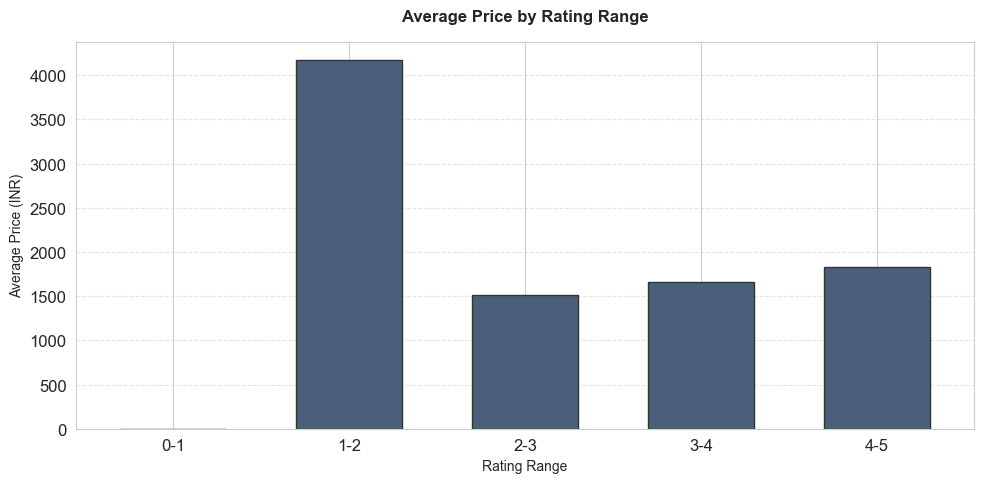

In [83]:
# 4. average price by rating range
rating_bins = pd.cut(df['rating'], bins=[0, 1, 2, 3, 4, 5],
                     labels=['0-1', '1-2', '2-3', '3-4', '4-5'])
price_by_rating = df.groupby(rating_bins, observed=False)['final_price'].mean()

plt.figure(figsize=(10, 5))
price_by_rating.plot(kind='bar', color='#4A607A', edgecolor='#333333', width=0.6)
plt.title('Average Price by Rating Range', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Rating Range', fontsize=10)
plt.ylabel('Average Price (INR)', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 7: Key Findings and Insights

In [84]:
# printing a final summary of the dataset
print("=" * 60)
print("              DATASET SUMMARY REPORT")
print("=" * 60)
print(f"  Total Products Analysed     : {len(df)}")
print(f"  Number of Categories        : {df['category'].nunique()}")
print(f"  Average Product Rating      : {df['rating'].mean():.2f}")
print(f"  Average Final Price         : Rs. {df['final_price'].mean():.2f}")
print(f"  Average Discount            : {df['discount'].mean():.1f}%")
cat_mode = df['category'].value_counts()
print(f"  Most Common Category        : {cat_mode.index[0]} ({cat_mode.values[0]} products)")
most_rated_cat = df.groupby('category')['rating'].mean()
print(f"  Highest Rated Category      : {most_rated_cat.idxmax()} (avg rating: {most_rated_cat.max():.2f})")
most_expensive = df.groupby('category')['final_price'].mean()
print(f"  Most Expensive Category     : {most_expensive.idxmax()} (avg: Rs. {most_expensive.max():.2f})")
print("=" * 60)

              DATASET SUMMARY REPORT
  Total Products Analysed     : 1000
  Number of Categories        : 97
  Average Product Rating      : 3.62
  Average Final Price         : Rs. 1706.10
  Average Discount            : 47.0%
  Most Common Category        : tops (122 products)
  Highest Rated Category      : cutlery (avg rating: 5.00)
  Most Expensive Category     : trolley-bag (avg: Rs. 17995.00)


### Key Findings

1. **Product Distribution is Uneven**: Fashion categories like tops, dresses and shirts dominate the dataset with the most number of listings. Home and lifestyle categories have comparatively fewer products.

2. **Pricing is Skewed Towards the Affordable Range**: The price distribution is right-skewed — majority of products are priced under Rs. 3,000 with a long tail of expensive items. This indicates the platform caters largely to budget and mid-range shoppers.

3. **Discounts are Common but Vary Widely**: Most products have some level of discount applied. The average discount percentage differs across categories, which suggests category-specific pricing strategies.

4. **Ratings are Generally Positive**: Most products fall in the 3.5 to 4.5 rating range. Very few products have ratings below 2.0, which could indicate either good product quality or that poorly rated products get delisted over time.

5. **Popularity Depends on Both Rating and Review Volume**: The popularity score reveals that a product needs both a good rating AND a high number of reviews to rank well. Some niche categories have high ratings but low popularity due to fewer reviews.

6. **Initial Price and Final Price are Strongly Correlated**: As expected, the correlation between initial and final prices is strong. The price difference (savings) varies, with some categories offering significantly higher absolute savings.

7. **Missing Data is Concentrated in Specific Columns**: Videos, customer feedback text and seller information have the most missing values. This is reasonable since not every listing will have video content or detailed seller data.

### Business Implications

- **Category Strategy**: The platform should continue investing in top categories (tops, dresses, shirts) while exploring growth in underrepresented but high-rating categories.
- **Pricing Decisions**: Understanding the discount-price relationship can help optimise discount strategies — offering the right discount level to maximise conversions without eroding margins.
- **Review Encouragement**: Products with high ratings but low review counts represent an opportunity. Encouraging customers to leave reviews on these products could boost their visibility and sales.
- **Data Quality Improvement**: Filling in missing seller information and encouraging video uploads could improve the overall shopping experience and build customer trust.